### Rank Histogram Analysis for Ensemble Kalman Filter

In [44]:
from diffrax import diffeqsolve, ODETerm,VirtualBrownianTree,MultiTerm,ControlTerm
from jax.scipy.stats import norm, poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

In [45]:
def rhs(t,state,args):

    sigma,rho,beta = args
    x,y,z = state

    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x*y - beta * z

    return jnp.array([dx,dy,dz])



In [46]:
'''The model integrator. Takes the length of time to integrate, the initial condition, and a parameter vector.'''
def model(ts,y0,par):
  solution = diffrax.diffeqsolve(
            ODETerm(rhs),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=1e-3,
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=ts),
            stepsize_controller = diffrax.PIDController(1e-3,1e-3)
        )
  return solution.ys

In [47]:
t_vec = jnp.linspace(0,15,750)

rng_key = jax.random.PRNGKey(1)

noise_key,rng_key = jax.random.split(rng_key)

'''Simulate model'''

num_models = 1000

IC_perturbation_scale = 1.0
noise_IC_key,rng_key = jax.random.split(rng_key)
params = (10.,28.,8/3)
x0 = jnp.array([[0.0,0.5,0.1]])
IC = jax.random.multivariate_normal(noise_IC_key,mean = x0, cov = IC_perturbation_scale * jnp.eye(3),shape = (num_models))

full_state = jax.vmap(model,in_axes = (None,0,None))(t_vec,IC,params)


# Generate noisy observations of the first state component x(t) with additive Gaussian noise ~N(0,1).
last_obs = 600
t_vec_obs = t_vec[:last_obs]
noise_std = 1.2
observations = full_state[:,:last_obs,0] + noise_std * jax.random.normal(noise_key,shape = full_state[:,:last_obs,0].shape)

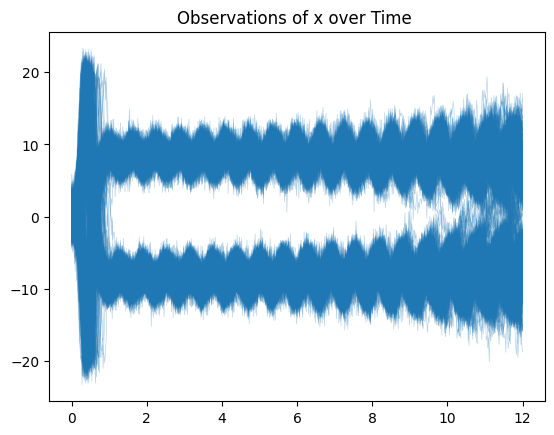

In [48]:
plt.title('Observations of x over Time ')
plt.plot(t_vec_obs,observations.T,color = "tab:blue",zorder = 100,alpha = 0.3,lw = 0.5)
#plt.plot(t_vec,full_state[:,0],label = 'True Value',color = "tab:red",zorder = 100)
plt.show()

In [49]:
def ensemble_kalman_filter(observations, delta_t, initial_ensemble, key, R_obs):
    def kalman_step(state, i):
        prev_ensemble, prev_key = state
        forecast_ensemble = jax.vmap(model, in_axes=(None, 0, None))(
            jnp.linspace(0, delta_t, 10), prev_ensemble, (10.0, 28.0, 8 / 3)
        )[:, -1, :]

        mean = jnp.mean(forecast_ensemble, axis=0)
        state_perturbation_matrix = (
            1 / jnp.sqrt(len(forecast_ensemble) - 1) * (forecast_ensemble - mean)
        ).squeeze()

        obs_mean = mean[0]
        obs_perturbation_matrix = (
            1
            / jnp.sqrt(len(forecast_ensemble) - 1)
            * (forecast_ensemble[:, 0] - obs_mean)
        )

        cross_cov = state_perturbation_matrix.T @ obs_perturbation_matrix

        S = (
            obs_perturbation_matrix.T
            @ obs_perturbation_matrix
        ) + R_obs

        S_inv = jnp.linalg.pinv(S)

        def update_step(member, observation, key):

            perturbed_observation = observation + R_obs * jax.random.normal(
                key
            )

            innovation = perturbed_observation - member[0]
            alpha = S_inv @ jnp.array([innovation])
            member = member + cross_cov @ alpha

            return member

        update_key,curr_key = jax.random.split(prev_key)
        update_keys = jax.random.split(update_key,len(forecast_ensemble))
        update_ensemble = jax.vmap(update_step, in_axes=(0, None, 0))(
            forecast_ensemble, observations[i], update_keys
        )

        return (update_ensemble, curr_key), update_ensemble

    return jax.lax.scan(kalman_step, (initial_ensemble, key), xs = jnp.arange(0,len(observations)))


In [50]:
ensemble_key, rng_key = jax.random.split(rng_key)
num_ensemble_members = 25
init_ensemble = jax.random.multivariate_normal(
    ensemble_key,
    mean=jnp.zeros(3),
    cov=0.1 * jnp.eye(3),
    shape=(num_models, num_ensemble_members),
)[..., jnp.newaxis]


inflated_obs_noise = 1.0 * noise_std**2

inference_key, rng_key = jax.random.split(rng_key)
inference_keys = jax.random.split(inference_key, num_models)
_, output = jax.vmap(ensemble_kalman_filter, in_axes=(0, None, 0, 0, None))(
    observations, t_vec[1] - t_vec[0], init_ensemble, inference_keys, inflated_obs_noise
)


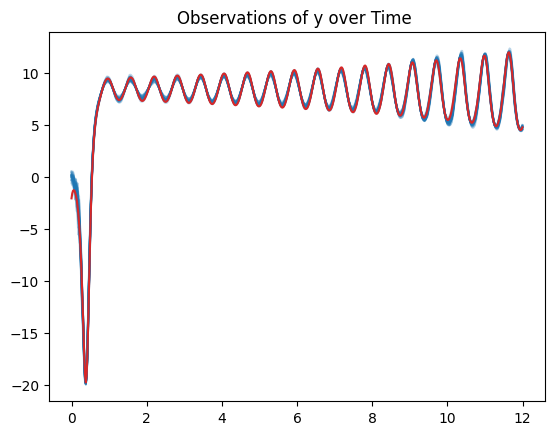

In [51]:
plt.title('Observations of y over Time ')
plt.plot(t_vec_obs,full_state[0,:last_obs,0],color = 'tab:red',zorder = 100)
plt.plot(t_vec_obs,output[0,:,:,0].squeeze(),color = 'tab:blue',alpha = 0.3)
plt.show()

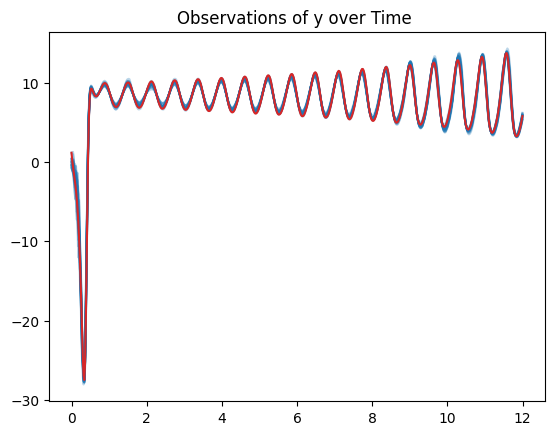

In [52]:
plt.title('Observations of y over Time ')
plt.plot(t_vec_obs,full_state[0,:last_obs,1],color = 'tab:red',zorder = 100)
plt.plot(t_vec_obs,output[0,:,:,1].squeeze(),color = 'tab:blue',alpha = 0.3)
plt.show()

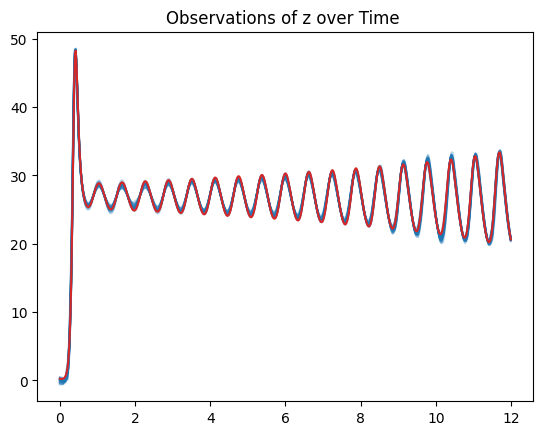

In [53]:
plt.title('Observations of z over Time ')
plt.plot(t_vec_obs,full_state[0,:last_obs,2],color = 'tab:red',zorder = 100)
plt.plot(t_vec_obs,output[0,:,:,2].squeeze(),color = 'tab:blue',alpha = 0.3)
plt.show()

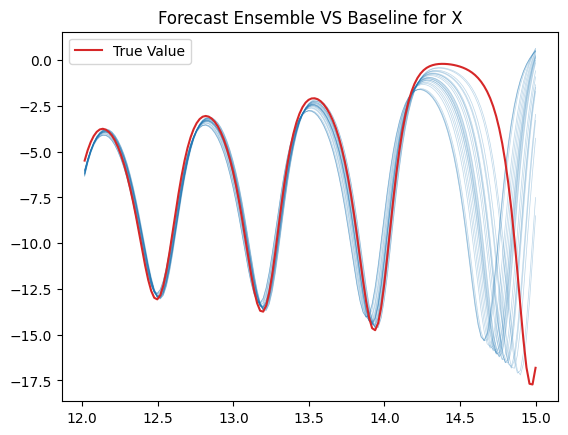

In [54]:
### Forecast
init_cond = output[:, -1, :, :, :].squeeze()

init_forecast_key, rng_key = jax.random.split(rng_key)

params_forecast = (10.,28.,8/3)

def forecast_run(IC, params):
    forecast = jax.vmap(model, in_axes=(None, 0, None))(t_vec[last_obs:], IC, params)

    return forecast

forecast = jax.vmap(forecast_run, in_axes=(0, None))(init_cond, params_forecast)

plt.title("Forecast Ensemble VS Baseline for X")
plt.plot(
    t_vec[last_obs:],
    full_state[1, last_obs:, 0],
    color="tab:red",
    zorder=100,
    label="True Value",
)
plt.plot(t_vec[last_obs:], forecast[1, :, :, 0].T, color="tab:blue", alpha=0.3, lw=0.5)
plt.legend()
plt.show()

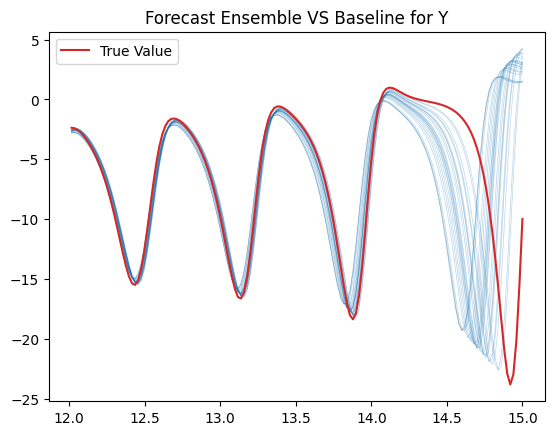

In [55]:
plt.title('Forecast Ensemble VS Baseline for Y')
plt.plot(t_vec[last_obs:],full_state[1,last_obs:,1],color = 'tab:red',zorder = 100,label = 'True Value')
plt.plot(t_vec[last_obs:],forecast[1,:,:,1].T,color = 'tab:blue',alpha = 0.3,lw = 0.5)
plt.legend()
plt.show()

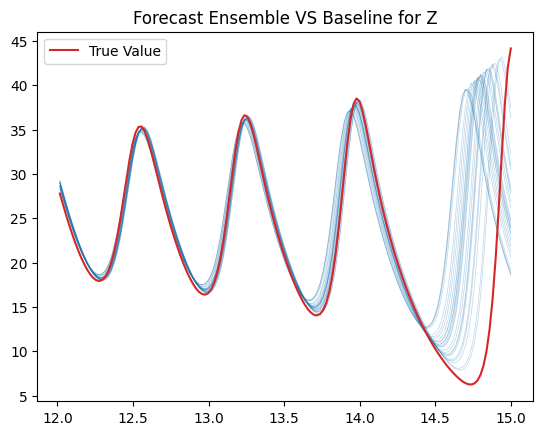

In [56]:
plt.title('Forecast Ensemble VS Baseline for Z')
plt.plot(t_vec[last_obs:],full_state[1,last_obs:,2],color = 'tab:red',zorder = 100,label = 'True Value')
plt.plot(t_vec[last_obs:],forecast[1,:,:,2].T,color = 'tab:blue',alpha = 0.3,lw = 0.5)
plt.legend()
plt.show()

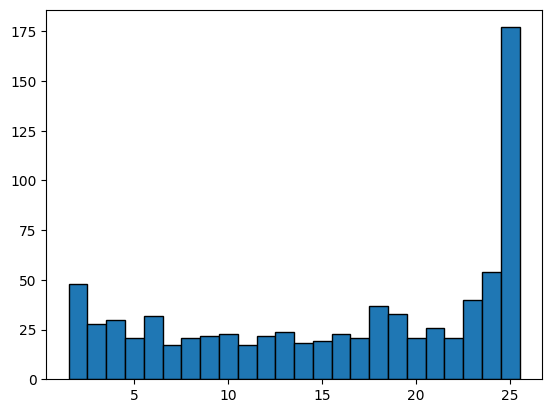

In [57]:
def get_rank_histogram(truth, ensemble):

    def rank_eval(ens, obs):
        is_smaller = ens < obs
        num_smaller = jnp.sum(is_smaller,axis = 0)

        return num_smaller

    ranks = jax.vmap(rank_eval, in_axes=(0, 0))(ensemble, truth)

    return ranks

lorenz_ranks = get_rank_histogram(full_state[:,-1,0],forecast[:,:,-1,0])

plt.hist(lorenz_ranks.reshape(-1),bins=jnp.arange(num_ensemble_members) + 2 - 0.5, edgecolor='black')
plt.show()

In [58]:
num_bins = num_ensemble_members + 1
rank_counts = jnp.bincount(lorenz_ranks.reshape(-1), length=num_bins)

total_observations = lorenz_ranks.shape[0]
expected_val = total_observations / num_bins
expected_counts = jnp.full(num_bins, expected_val)

def chi_square_test(observed, expected): 
    return jnp.sum(jnp.square(observed - expected) / expected)

stat = chi_square_test(rank_counts, expected_counts)
df = num_bins - 1

p_value = jax.scipy.stats.chi2.sf(stat, df)

print(f"Chi2 Stat: {stat:.2f}, df: {df}, p-value: {p_value:.4f}")

Chi2 Stat: 960.35, df: 25, p-value: 0.0000


In [59]:
'''Baseline Normal Distribution'''

def get_rank_histogram(truth,ensemble): 
    obs = truth
    ens = ensemble

    is_smaller = ens < obs
    ranks = jnp.sum(is_smaller,axis = 0)
    return ranks

rng_key,truth_key = jax.random.split(rng_key)

num_truth_points = 100000
num_ensemble_members = 20
mu = 0.1
sigma = 1.0

V = jax.random.normal(truth_key, shape = (num_truth_points,))
forecast_key, rng_key = jax.random.split(rng_key)
forecast = mu + sigma * jax.random.normal(forecast_key, shape  = (num_ensemble_members, num_truth_points))

norm_ranks = get_rank_histogram(V,forecast)

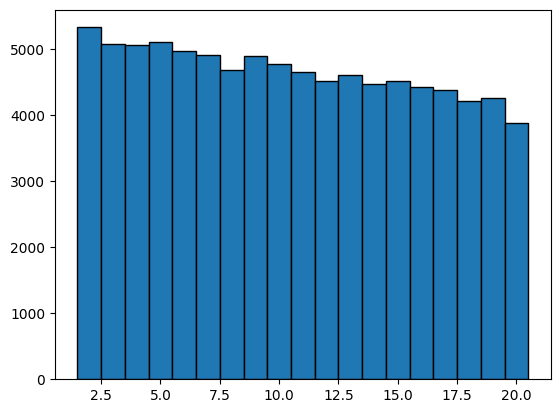

In [60]:
plt.hist(norm_ranks,bins=jnp.arange(num_ensemble_members) + 2 - 0.5, edgecolor='black')
plt.show()

In [61]:
num_bins = num_ensemble_members + 1
rank_counts = jnp.bincount(norm_ranks, length=num_bins)

total_observations = norm_ranks.shape[0]
expected_val = total_observations / num_bins
expected_counts = jnp.full(num_bins, expected_val)

def chi_square_test(observed, expected): 
    return jnp.sum(jnp.square(observed - expected) / expected)

stat = chi_square_test(rank_counts, expected_counts)
df = num_bins - 1

p_value = jax.scipy.stats.chi2.sf(stat, df)

print(f"Chi2 Stat: {stat:.2f}, df: {df}, p-value: {p_value:.4f}")

Chi2 Stat: 848.67, df: 20, p-value: 0.0000
